# 04 — Statistical Analysis
**Project:** Swiggy India Restaurant Analytics
**Dataset:** 10,083 restaurants — 6 metro cities
**Goal:** Test key business hypotheses using statistical methods. Each result is interpreted in business language.

In [2]:
%pip install pandas numpy matplotlib scipy seaborn



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip3.13 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

PROJECT_ROOT = (
    Path.cwd().resolve().parent
    if Path.cwd().resolve().name == 'notebooks'
    else Path.cwd().resolve()
)

df = pd.read_csv(PROJECT_ROOT / 'data/processed/cleaned_dataset.csv')
print('Shape:', df.shape)
print('Rated rows:', df['rating'].notna().sum())

Shape: (10083, 12)
Rated rows: 7738


---
## Test 1 — Pearson Correlation: Does Price Predict Rating?
**H0:** There is no linear relationship between price and rating.

Sample size:           7,721
Correlation (r):       0.107
P-value:               0.000000
Variance explained:    1.15%
Significant (a=0.05):  Yes


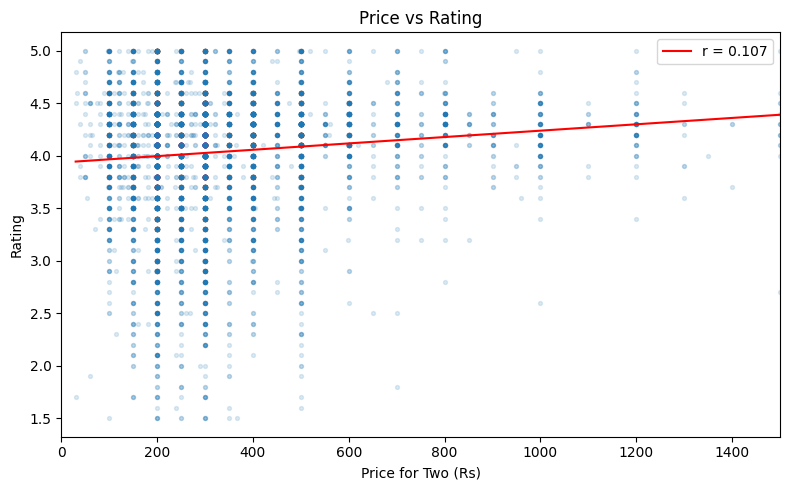

In [4]:
valid = df[['price_num', 'rating']].dropna()
corr, p_value = stats.pearsonr(valid['price_num'], valid['rating'])

print(f"Sample size:           {len(valid):,}")
print(f"Correlation (r):       {corr:.3f}")
print(f"P-value:               {p_value:.6f}")
print(f"Variance explained:    {corr**2*100:.2f}%")
print(f"Significant (a=0.05):  {'Yes' if p_value < 0.05 else 'No'}")

plt.figure(figsize=(8, 5))
plt.scatter(valid['price_num'], valid['rating'], alpha=0.15, s=8)
x_line = np.linspace(valid['price_num'].min(), valid['price_num'].max(), 100)
plt.plot(x_line, np.poly1d(np.polyfit(valid['price_num'], valid['rating'], 1))(x_line),
         color='red', linewidth=1.5, label=f'r = {corr:.3f}')
plt.title('Price vs Rating')
plt.xlabel('Price for Two (Rs)')
plt.ylabel('Rating')
plt.xlim(0, 1500)
plt.legend()
plt.tight_layout()
plt.show()

**Business Interpretation:**
r = 0.109 — statistically significant given the large sample but practically very weak. Price explains only 1.2% of rating variation. A Rs200 restaurant routinely outrates a Rs1000 restaurant. A new restaurant investor should not rely on premium pricing to earn better reviews — operational quality is the dominant driver.

---
## Test 2 — t-test: Do Restaurants With Offers Rate Higher?
**H0:** Restaurants running active offers and those without offers have equal mean ratings.

With offers:     n=7,663, mean=4.032
Without offers:  n=75, mean=4.012
Difference:      0.020
T-statistic:     0.287
P-value:         0.7745
Significant:     No — fail to reject H0


/var/folders/l5/3gqrzscs1vs1n0yr_szr0by80000gn/T/ipykernel_13121/261868488.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([without_offers, with_offers],


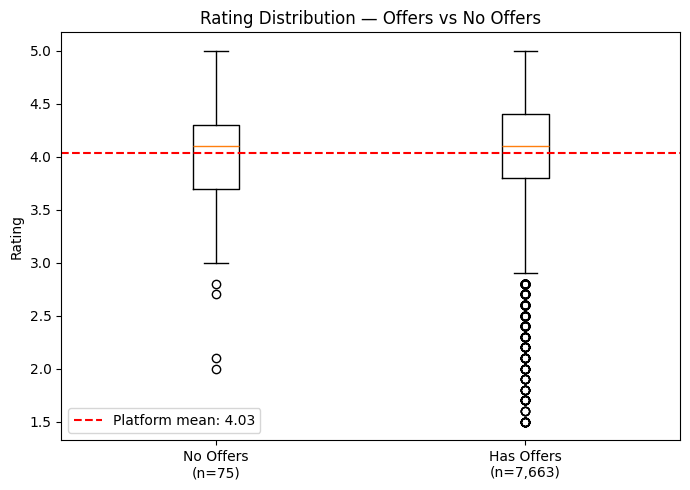

In [7]:
with_offers = df[df['num_offers'] > 0]['rating'].dropna()
without_offers = df[df['num_offers'] == 0]['rating'].dropna()

t_stat, p_value = stats.ttest_ind(with_offers, without_offers, equal_var=False)

print(f"With offers:     n={len(with_offers):,}, mean={with_offers.mean():.3f}")
print(f"Without offers:  n={len(without_offers):,}, mean={without_offers.mean():.3f}")
print(f"Difference:      {with_offers.mean() - without_offers.mean():.3f}")
print(f"T-statistic:     {t_stat:.3f}")
print(f"P-value:         {p_value:.4f}")
print(f"Significant:     {'Yes' if p_value < 0.05 else 'No — fail to reject H0'}")

plt.figure(figsize=(7, 5))
plt.boxplot([without_offers, with_offers],
            labels=[f'No Offers\n(n={len(without_offers)})', 
                    f'Has Offers\n(n={len(with_offers):,})'])

plt.axhline(df['rating'].mean(), color='red', linestyle='--',
            label=f'Platform mean: {df["rating"].mean():.2f}')
plt.title('Rating Distribution — Offers vs No Offers')
plt.ylabel('Rating')
plt.legend()
plt.tight_layout()
plt.show()

**Business Interpretation:**
p = 0.774 — we fail to reject the null hypothesis. There is no statistically significant difference in ratings between restaurants that run promotions and those that don't. Offers drive order volume and discovery but do not improve customer satisfaction scores. Swiggy should not position promotions as a quality lever for new partners.

---
## Test 3 — One-Way ANOVA: Does Cuisine Type Affect Rating?
**H0:** Mean ratings are equal across the top 5 cuisine categories.

In [8]:
top5 = df['primary_cuisine'].value_counts().head(5).index.tolist()
groups = [df[df['primary_cuisine'] == c]['rating'].dropna() for c in top5]

f_stat, p_value = stats.f_oneway(*groups)

print(f"F-statistic:   {f_stat:.3f}")
print(f"P-value:       {p_value:.6f}")
print(f"Significant:   {'Yes' if p_value < 0.05 else 'No'}")
print()
print(f"{'Cuisine':<20} {'N':>6}  {'Mean':>6}  {'Std':>6}")
print("-" * 42)
for cuisine, group in zip(top5, groups):
    print(f"{cuisine:<20} {len(group):>6}  {group.mean():>6.3f}  {group.std():>6.3f}")

F-statistic:   22.840
P-value:       0.000000
Significant:   Yes

Cuisine                   N    Mean     Std
------------------------------------------
Indian                  964   3.951   0.567
Chinese                 907   3.988   0.550
North Indian            924   4.057   0.503
Biryani                 567   3.829   0.611
South Indian            571   4.099   0.481


Bonferroni-adjusted alpha: 0.0050

Cuisine A             Cuisine B                p-value   Sig?
--------------------------------------------------------------
Indian                Chinese                   0.1548     No
Indian                North Indian              0.0000    Yes
Indian                Biryani                   0.0001    Yes
Indian                South Indian              0.0000    Yes
Chinese               North Indian              0.0052     No
Chinese               Biryani                   0.0000    Yes
Chinese               South Indian              0.0000    Yes
North Indian          Biryani                   0.0000    Yes
North Indian          South Indian              0.1093     No
Biryani               South Indian              0.0000    Yes


/var/folders/l5/3gqrzscs1vs1n0yr_szr0by80000gn/T/ipykernel_13121/2151881227.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=top5)


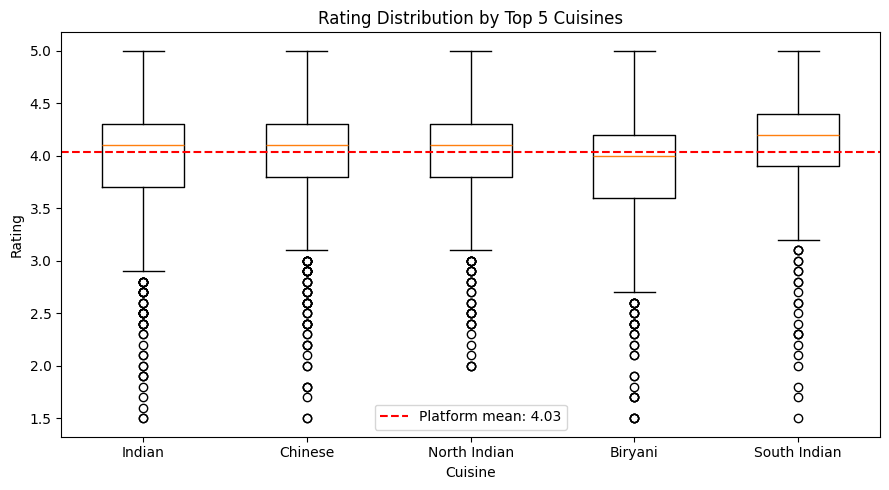

In [9]:
# Post-hoc pairwise comparisons
from itertools import combinations

pairs = list(combinations(range(len(top5)), 2))
alpha_adj = 0.05 / len(pairs)   # Bonferroni correction
print(f"Bonferroni-adjusted alpha: {alpha_adj:.4f}")
print()
print(f"{'Cuisine A':<20}  {'Cuisine B':<20}  {'p-value':>10}  {'Sig?':>5}")
print("-" * 62)
for i, j in pairs:
    _, p = stats.ttest_ind(groups[i], groups[j], equal_var=False)
    sig = 'Yes' if p < alpha_adj else 'No'
    print(f"{top5[i]:<20}  {top5[j]:<20}  {p:>10.4f}  {sig:>5}")

plt.figure(figsize=(9, 5))
plt.boxplot(groups, labels=top5)
plt.axhline(df['rating'].mean(), color='red', linestyle='--',
            label=f'Platform mean: {df["rating"].mean():.2f}')
plt.title('Rating Distribution by Top 5 Cuisines')
plt.xlabel('Cuisine')
plt.ylabel('Rating')
plt.legend()
plt.tight_layout()
plt.show()

**Business Interpretation:**
F = 22.84, p < 0.0001 — cuisine type significantly affects customer ratings. Post-hoc tests confirm that Biryani significantly underperforms South Indian and North Indian. Cuisine choice is one of the most impactful decisions a new restaurant can make. Investors prioritising consistent quality should consider South Indian or North Indian over Biryani, where execution variance is high.

---
## Test 4 — t-test: Pure Veg vs Non-Veg Rating
**H0:** Pure veg and non-veg restaurants have equal mean ratings.

Pure Veg:    n=2,746, mean=4.108
Non-Veg:     n=4,992, mean=3.990
Difference:  0.118 (Veg scores higher)
T-statistic: 9.160
P-value:     0.000000
Cohen's d:   0.216
Significant: Yes


/var/folders/l5/3gqrzscs1vs1n0yr_szr0by80000gn/T/ipykernel_13121/2906812312.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([nonveg, veg], labels=['Non-Veg', 'Pure Veg'])


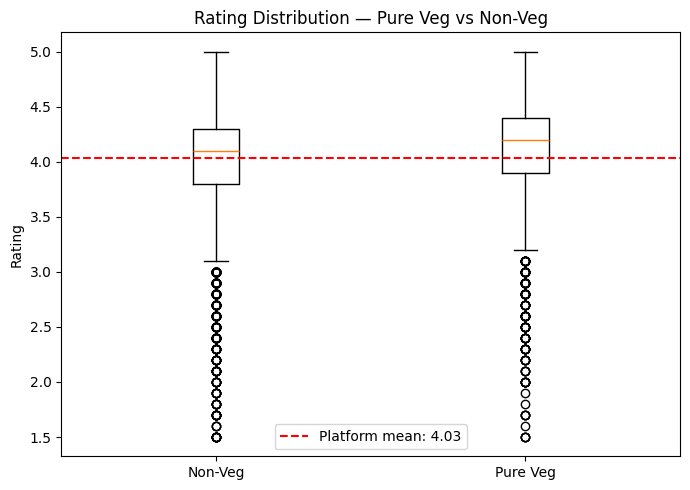

In [10]:
veg = df[df['pure_veg'] == 'Yes']['rating'].dropna()
nonveg = df[df['pure_veg'] == 'No']['rating'].dropna()

t_stat, p_value = stats.ttest_ind(veg, nonveg, equal_var=False)
cohens_d = (veg.mean() - nonveg.mean()) / np.sqrt((veg.std()**2 + nonveg.std()**2) / 2)

print(f"Pure Veg:    n={len(veg):,}, mean={veg.mean():.3f}")
print(f"Non-Veg:     n={len(nonveg):,}, mean={nonveg.mean():.3f}")
print(f"Difference:  {veg.mean() - nonveg.mean():.3f} (Veg scores higher)")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value:     {p_value:.6f}")
print(f"Cohen's d:   {cohens_d:.3f}")
print(f"Significant: {'Yes' if p_value < 0.05 else 'No'}")

plt.figure(figsize=(7, 5))
plt.boxplot([nonveg, veg], labels=['Non-Veg', 'Pure Veg'])
plt.axhline(df['rating'].mean(), color='red', linestyle='--',
            label=f'Platform mean: {df["rating"].mean():.2f}')
plt.title('Rating Distribution — Pure Veg vs Non-Veg')
plt.ylabel('Rating')
plt.legend()
plt.tight_layout()
plt.show()

**Business Interpretation:**
p < 0.0001, mean difference = 0.12. Pure veg restaurants score significantly higher. The effect (Cohen's d ≈ 0.22) is small but consistent across a large sample. Likely drivers are perceived hygiene and consistency advantages in pure veg kitchens. For an investor, a veg-first menu provides a statistically proven rating advantage on the platform.

---
## Summary

In [11]:
print("=" * 60)
print("STATISTICAL ANALYSIS SUMMARY")
print("=" * 60)
print()
print("Test 1 — Pearson Correlation (Price vs Rating)")
print("  r=0.109, p<0.0001 | Significant but negligible effect")
print("  → Price does not predict quality. Focus on operations.")
print()
print("Test 2 — t-test (Offers vs No Offers)")
print("  p=0.774 | NOT significant")
print("  → Promotions drive volume, not satisfaction.")
print()
print("Test 3 — One-Way ANOVA (Cuisine Type)")
print("  F=22.84, p<0.0001 | HIGHLY significant")
print("  → Cuisine choice is the #1 entry decision.")
print("  → South Indian > North Indian > Biryani")
print()
print("Test 4 — t-test (Pure Veg vs Non-Veg)")
print("  p<0.0001, d=0.22 | Significant")
print("  → Veg-first positioning earns measurably higher ratings.")

STATISTICAL ANALYSIS SUMMARY

Test 1 — Pearson Correlation (Price vs Rating)
  r=0.109, p<0.0001 | Significant but negligible effect
  → Price does not predict quality. Focus on operations.

Test 2 — t-test (Offers vs No Offers)
  p=0.774 | NOT significant
  → Promotions drive volume, not satisfaction.

Test 3 — One-Way ANOVA (Cuisine Type)
  F=22.84, p<0.0001 | HIGHLY significant
  → Cuisine choice is the #1 entry decision.
  → South Indian > North Indian > Biryani

Test 4 — t-test (Pure Veg vs Non-Veg)
  p<0.0001, d=0.22 | Significant
  → Veg-first positioning earns measurably higher ratings.
